# Tree Cover on Cropland and in Cities

Sustainable development goal (SDG) 15 aims to “protect, restore and promote sustainable use of terrestrial ecosystems, sustainably manage forests, combat desertification, and halt and reverse land degradation and halt biodiversity loss.” I chose this because it’s an interesting topic with large amounts of various data, and it can be approached from many different angles.

In this notebook I try to find and visualize something interesting about tree cover on cropland and cities in tropical countries. SDG 15 is often about wilderness, but the dataset here is about land that people already farm and live on. It covers 94 tropical countries from 6 regions.

**Data.** Brandt, J., Ertel, J., Spore, J. et al. *The extent of trees in the tropics* (2022),
preprint, Research Square, [doi:10.21203/rs.3.rs-2109093/v1](https://doi.org/10.21203/rs.3.rs-2109093/v1).
The figures used here are Table 1 of the supplementary index: for each tropical country, the
share of cropland and of urban area with at least 10% tree cover, and the average tree cover
on each.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

In [2]:
trees = pd.read_csv("../data/tree_data.csv", sep=";")

# The source table only names a region on its first row per group.
trees["Region"] = trees["Region"].ffill()

trees.head()

,Region,Country,Land Cover,Land with >=10% cover (%),Avg tree cover (%)
0,Latin America,Mexico,Cropland,52.58,29.71
1,Latin America,Mexico,Urban,49.30,19.48
2,Latin America,Argentina,Cropland,42.65,28.52
3,Latin America,Argentina,Urban,55.63,25.11
4,Latin America,Belize,Cropland,42.24,23.84


## Where do trees survive on converted land?

Let's look at the differences between regions and cropland vs urban areas. The chart shows mean tree cover per region, split by cropland vs urban.

Regions are ordered by mean cropland tree cover from most to least to make comparisons easier.

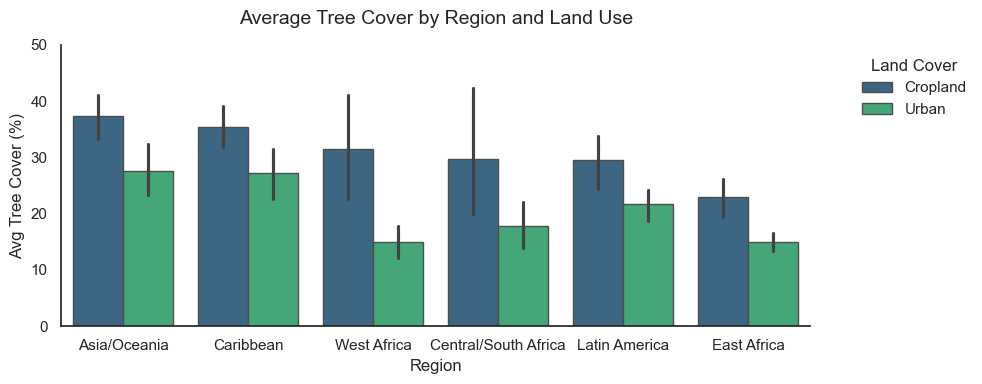

In [3]:
cropland_order = (
    trees[trees["Land Cover"] == "Cropland"]
    .groupby("Region")["Avg tree cover (%)"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.set_theme(style="white")
plt.figure(figsize=(10, 4))

sns.barplot(
    data=trees,
    x="Region",
    y="Avg tree cover (%)",
    hue="Land Cover",
    order=cropland_order,
    palette="viridis",
    edgecolor="0.3",
)

plt.ylim(0, 50)
plt.title("Average Tree Cover by Region and Land Use", fontsize=14, pad=15)
plt.ylabel("Avg Tree Cover (%)", fontsize=12)
plt.xlabel("Region", fontsize=12)
plt.legend(title="Land Cover", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("../figures/01-tree-cover-by-region.png", dpi=150, bbox_inches="tight")
plt.show()

As expected, tree cover is higher on croplands than urban areas in every region without exception. However, the gaps are not constant. It seems that farm and city tree cover broadly move together regardless of the region. Are they separate or do they correlate with each other? Let's explore that at country level as six regions is a small, aggregated view.

## Are they correlated?

A scatter plot needs two values per point, so let's pivot the table so that each country has one row with both land cover types instead of two rows, one for each.

In [4]:
by_country = trees.pivot_table(
    index="Country",
    columns="Land Cover",
    values="Avg tree cover (%)",
    aggfunc="mean",
)

by_country.head()

Land Cover,Cropland,Urban
Country,,
Angola,25.86,12.58
Argentina,28.52,25.11
Australia,19.95,20.91
Bangladesh,30.42,31.35
Belize,23.84,23.01


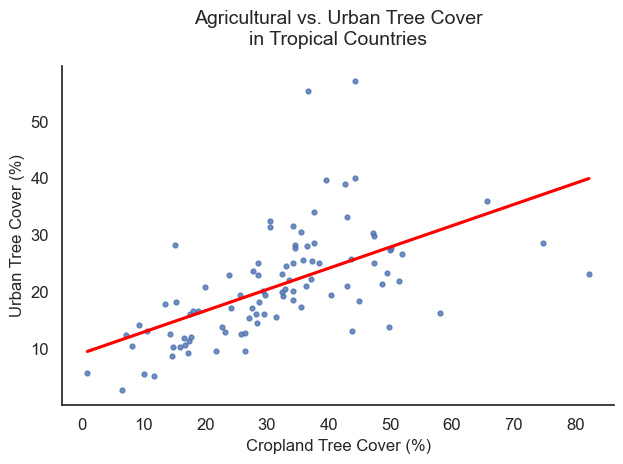

In [5]:
sns.regplot(
    data=by_country,
    x="Cropland",
    y="Urban",
    line_kws={"color": "red"},
    scatter_kws={"s": 12},
    ci=None,
)

plt.title("Agricultural vs. Urban Tree Cover\nin Tropical Countries", fontsize=14, pad=15)
plt.xlabel("Cropland Tree Cover (%)", fontsize=12)
plt.ylabel("Urban Tree Cover (%)", fontsize=12)
plt.tick_params(labelsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("../figures/01-tree-cover-correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Correlation and slope:

In [6]:
from scipy.stats import linregress

fit = linregress(by_country["Cropland"], by_country["Urban"])

by_country["Predicted"] = fit.slope * by_country["Cropland"] + fit.intercept
by_country["Residual"] = by_country["Urban"] - by_country["Predicted"]

print(f"r = {fit.rvalue:.3f}   r^2 = {fit.rvalue**2:.3f}")
print(f"Urban = {fit.slope:.3f} * Cropland + {fit.intercept:.2f}")

r = 0.573   r^2 = 0.328
Urban = 0.374 * Cropland + 9.18


Let's see what the biggest outliers are.

In [7]:
by_country.nlargest(5, "Residual")[["Cropland", "Urban", "Residual"]].round(1)

Land Cover,Cropland,Urban,Residual
Country,,,
Vanuatu,36.6,55.4,32.5
Solomon Islands,44.3,57.1,31.4
Fiji,39.6,39.7,15.7
India Islands,44.3,40.1,14.3
Sri Lanka,42.6,39.0,13.9


In [8]:
by_country.nsmallest(5, "Residual")[["Cropland", "Urban", "Residual"]].round(1)

Land Cover,Cropland,Urban,Residual
Country,,,
Liberia,82.2,23.1,-16.9
Sierra Leone,58.0,16.3,-14.6
Ivory Coast,49.8,13.8,-14.1
East Timor,43.8,13.2,-12.4
Nigeria,26.4,9.6,-9.5


## The results

The scatterplot reveals that there's a light correlation of 0.573, indicating that they might be connected and that tropical countries with more urban tree cover might have more tree cover on croplands as well.

As the slope is 0.374 (well below 1), more farm tree cover doesn't mean urban tree cover grows proportionally as much. The line doesn't work backwards either: the countries with the most urban tree cover are not the ones with the most on their farms.

Nice to know: Vanuatu and Solomon Islands have *more* tree cover on urban areas than on croplands.

**Design notes:** I chose to exclude the confidence interval as well as the top and right spines from the plot as I thought they didn’t add any valuable information to the visualization. The red regression line, being the most important message of the visualization, stands out from the blue dots representing where individual countries stand. Text and numbers are readable, as in not too large or small, and of appropriate weight. Axes do not need to reach 100 % because that is unnecessary information. Due to these choices, the data-ink ratio is high.